# Fourchette de prix + incertitude (french-second-hand-cars)

**Exigence produit OscarIA** : au lieu d'un prix ponctuel (« 18 400 € », faux à ~4 000 € près),
donner une **fourchette** « entre 16 000 € et 21 000 € » dont la **largeur = l'incertitude**.

**Méthode : régression quantile + calibration conforme.**
1. On entraîne 3 modèles quantile (q10 = borne basse, q50 = médiane, q90 = borne haute).
2. On **vérifie la couverture** (% de vrais prix dans la fourchette) → visée **80 %**.
3. Si la fourchette brute est mal calibrée, on la **corrige** (conformal / CQR) pour tenir la promesse.

> Périmètre (**scope**) réglable via `SEUIL` (par défaut 50 000 €). Le titre du graphique et les mesures s'adaptent au seuil choisi.

In [1]:
import sys, math
from pathlib import Path
sys.path.insert(0, "../../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score

from features import clean_cars, load_premium_table, add_brand_features

SEUIL = 50_000      # >>> RÉGLAGE : périmètre produit en euros (ex: 60_000) <<<
ALPHA = 0.20        # 1 - couverture visée -> 80 %

df = clean_cars("../../data/french-second-hand-cars/raw/French_second_hand_cars.csv")
df = add_brand_features(df, load_premium_table("../../references/premium_brand.csv"))
df = df[df["price"] <= SEUIL]
print(f"shape (scope ≤{SEUIL//1000}k):", df.shape)

shape (scope ≤50k): (2032, 51)


## 🟦 1. Features + double découpage

Pour la calibration conforme il faut **3 jeux** :
- **train_fit** : entraîne les modèles quantile,
- **calibration** : mesure de combien élargir la fourchette,
- **test** : évaluation finale, jamais vu.

In [2]:
features = ["age", "kilometrage", "puissance_din", "puissance_fisc",
            "nombredeportes", "nombredeplaces",
            "niveau", "boite_auto", "garantie_constructeur", "garantie_mois"]
data = df[features + ["price"]].dropna(subset=["price"])
X, y = data[features], data["price"]

# test à part, puis train -> train_fit + calibration
X_tr, X_test, y_tr, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_fit, X_cal, y_fit, y_cal = train_test_split(X_tr, y_tr, test_size=0.25, random_state=42)
print("fit:", len(X_fit), "| calibration:", len(X_cal), "| test:", len(X_test))

fit: 1218 | calibration: 407 | test: 407


## 🟩 2. Entraînement des 3 modèles quantile

Chaque modèle optimise une **pinball loss** (`loss="quantile"`) qui vise un quantile précis.

In [3]:
def fit_quantile(q):
    m = HistGradientBoostingRegressor(loss="quantile", quantile=q, random_state=42)
    return m.fit(X_fit, y_fit)

m10, m50, m90 = fit_quantile(0.10), fit_quantile(0.50), fit_quantile(0.90)
print("modèles q10 / q50 / q90 entraînés sur", len(X_fit), "voitures")

modèles q10 / q50 / q90 entraînés sur 1218 voitures


## 🟥 3. Fourchette BRUTE — et son problème de calibration

On prédit [q10, q90] sur le test et on mesure la **couverture réelle**.

In [4]:
def bornes(model_lo, model_hi, Xd):
    lo, hi = model_lo.predict(Xd), model_hi.predict(Xd)
    return np.minimum(lo, hi), np.maximum(lo, hi)   # garde-fou anti-croisement

lo_raw, hi_raw = bornes(m10, m90, X_test)
cov_raw = ((y_test.values >= lo_raw) & (y_test.values <= hi_raw)).mean() * 100
print(f"Couverture BRUTE : {cov_raw:.1f} %   (visé 80 %)")
print(f"Largeur médiane  : {np.median(hi_raw - lo_raw):,.0f} €")
print("\n=> si < 80 %, la fourchette est trop optimiste : on la calibre à l'étape suivante.")

Couverture BRUTE : 67.8 %   (visé 80 %)
Largeur médiane  : 7,317 €

=> si < 80 %, la fourchette est trop optimiste : on la calibre à l'étape suivante.


## 🟩 4. Calibration conforme (CQR)

Sur le jeu de **calibration**, on mesure de combien chaque vrai prix **dépasse** la fourchette :

`score = max(q10 − prix, prix − q90)`  (négatif si dedans, positif si dehors).

On prend le quantile 80 % de ces scores → un **coussin `Q`** qu'on ajoute de chaque côté.
Ça garantit ~80 % de couverture sur données neuves (garantie théorique du *conformal prediction*).

In [5]:
lo_cal, hi_cal = bornes(m10, m90, X_cal)
scores = np.maximum(lo_cal - y_cal.values, y_cal.values - hi_cal)

n = len(scores)
k = math.ceil((n + 1) * (1 - ALPHA))          # rang avec correction petit échantillon
k = min(k, n)
Q = np.sort(scores)[k - 1]
print(f"coussin de calibration Q = {Q:,.0f} €")

coussin de calibration Q = 1,306 €


## 🟥 5. Fourchette CALIBRÉE + validation

In [6]:
lo = lo_raw - Q
hi = hi_raw + Q
med = m50.predict(X_test)

dedans = (y_test.values >= lo) & (y_test.values <= hi)
cov = dedans.mean() * 100
largeur = hi - lo

print(f"Couverture CALIBRÉE : {cov:.1f} %   (visé 80 %)   [brute: {cov_raw:.1f} %]")
print(f"Largeur médiane     : {np.median(largeur):,.0f} €  ({np.median(largeur)/np.median(y_test)*100:.0f} % du prix médian)")
print(f"\nModèle médian (q50) — repère : MAE {mean_absolute_error(y_test, med):,.0f} € | R² {r2_score(y_test, med):.3f}")

Couverture CALIBRÉE : 80.3 %   (visé 80 %)   [brute: 67.8 %]
Largeur médiane     : 9,929 €  (44 % du prix médian)

Modèle médian (q50) — repère : MAE 3,284 € | R² 0.803


## 🟥 6. Exemples — 3 voitures et leur fourchette calibrée

In [7]:
ex = X_test.copy()
ex["prix_réel"] = y_test.values
ex["bas"], ex["est"], ex["haut"] = lo.round(-2), med.round(-2), hi.round(-2)
ex["largeur"] = (hi - lo).round(-2)

idx = [y_test.values.argmin(),
       np.abs(y_test.values - np.median(y_test)).argmin(),
       y_test.values.argmax()]
for i in idx:
    r = ex.iloc[i]
    ok = "✓" if r["bas"] <= r["prix_réel"] <= r["haut"] else "✗"
    print(f"{ok} réel {r['prix_réel']:>7,.0f} €  ->  [{r['bas']:>7,.0f} ; {r['haut']:>7,.0f}] €  (large {r['largeur']:,.0f} €)")
ex.iloc[idx][["prix_réel","bas","est","haut","largeur","age","kilometrage","niveau"]]

✗ réel   3,020 €  ->  [  3,700 ;  10,900] €  (large 7,200 €)
✓ réel  22,640 €  ->  [ 17,400 ;  29,100] €  (large 11,600 €)
✗ réel  49,960 €  ->  [ 28,700 ;  44,700] €  (large 15,900 €)


,prix_réel,bas,est,haut,largeur,age,kilometrage,niveau
1813,3020.0,3700.0,7000.0,10900.0,7200.0,16.0,127668.0,0
192,22640.0,17400.0,23600.0,29100.0,11600.0,3.0,21160.0,0
323,49960.0,28700.0,41200.0,44700.0,15900.0,3.0,66698.0,1


## 🟥 7. Bande d'incertitude (test trié par prix estimé)

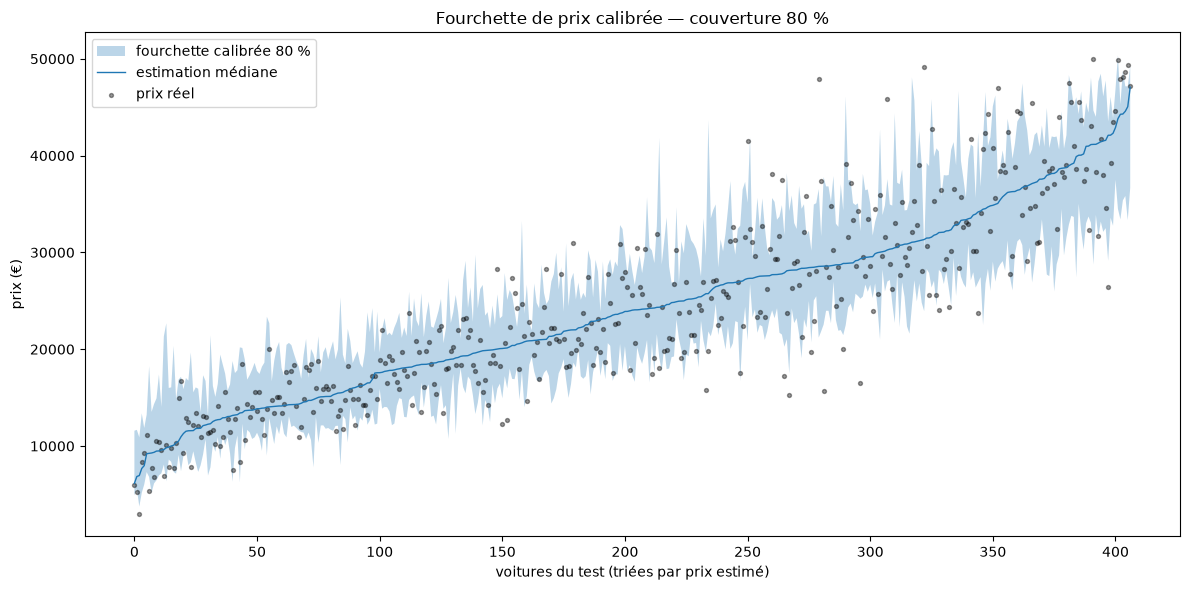

In [8]:
ordre = np.argsort(med)
xs = np.arange(len(ordre))
plt.figure(figsize=(12, 6))
plt.fill_between(xs, lo[ordre], hi[ordre], alpha=0.3, label="fourchette calibrée 80 %")
plt.plot(xs, med[ordre], color="C0", lw=1, label="estimation médiane")
plt.scatter(xs, y_test.values[ordre], s=8, color="k", alpha=0.4, label="prix réel")
plt.xlabel("voitures du test (triées par prix estimé)"); plt.ylabel("prix (€)")
plt.title(f"Fourchette de prix calibrée — couverture {cov:.0f} %")
plt.legend(); plt.tight_layout(); plt.show()

## Lecture (BC04) — exigence produit bouclée

- **La fourchette brute ne couvrait pas 80 %** (trop optimiste). La **calibration conforme** la
  corrige pour tenir sa promesse → l'incertitude devient **honnête et vérifiable**.
- **La couverture mesurée prouve la calibration** : on ne se contente pas d'afficher « 80 % », on
  le démontre sur des données jamais vues.
- **La largeur varie par voiture** = le modèle avoue quand il doute. Explicabilité, cœur du BC04.
- **Sortie directement produit** : « votre voiture vaut entre X et Y € ».
- **Limites** : couverture **globale** (peut varier par segment) ; le coussin `Q` est symétrique
  (même élargissement des deux côtés). Raffinements : CQR asymétrique, calibration par segment.